In [1]:
# MODEL EVALUATION & COMPARISON

import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')

X = data.drop("Encoded_Label", axis=1)
y = data["Encoded_Label"]

print("Dataset shape:", data.shape)

Dataset shape: (2520751, 81)


In [5]:
scaler = joblib.load(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\scaler.pkl")

X = X.select_dtypes(include=[np.number]).astype(np.float32)
X_scaled = scaler.transform(X)

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [7]:
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [8]:
rnn_model = tf.keras.models.load_model(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn_model_fixed.h5")
bilstm_model = tf.keras.models.load_model(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_model_fixed.h5")

In [9]:
print("===== RNN RESULTS =====")

rnn_loss, rnn_acc = rnn_model.evaluate(X_test_reshaped, y_test)

rnn_pred = rnn_model.predict(X_test_reshaped, batch_size=1024)
rnn_pred_classes = rnn_pred.argmax(axis=1)

print("RNN Accuracy:", rnn_acc)
print(classification_report(y_test, rnn_pred_classes, digits=4))

===== RNN RESULTS =====
11817/11817 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9525 - loss: 0.1372
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
RNN Accuracy: 0.9524771571159363
              precision    recall  f1-score   support

           0     0.9989    0.9442    0.9708    314259
           1     0.0451    0.8767    0.0858       292
           2     0.8699    0.9738    0.9189      1373
           3     0.9183    0.9989    0.9569     19202
           4     0.8982    0.9903    0.9420     29062
           5     0.7231    0.9974    0.8384     13604
           6     0.1421    0.9595    0.2475       321

    accuracy                         0.9525    378113
   macro avg     0.6565    0.9630    0.7086    378113
weighted avg     0.9752    0.9525    0.9616    378113



In [10]:
print("===== BiLSTM RESULTS =====")

bilstm_loss, bilstm_acc = bilstm_model.evaluate(X_test_reshaped, y_test)

bilstm_pred = bilstm_model.predict(X_test_reshaped, batch_size=1024)
bilstm_pred_classes = bilstm_pred.argmax(axis=1)

print("BiLSTM Accuracy:", bilstm_acc)
print(classification_report(y_test, bilstm_pred_classes, digits=4))

===== BiLSTM RESULTS =====
11817/11817 ━━━━━━━━━━━━━━━━━━━━ 96s 8ms/step - accuracy: 0.9494 - loss: 0.1585
370/370 ━━━━━━━━━━━━━━━━━━━━ 35s 95ms/step
BiLSTM Accuracy: 0.9494330883026123
              precision    recall  f1-score   support

           0     0.9987    0.9406    0.9688    314259
           1     0.0903    0.7397    0.1610       292
           2     0.6906    0.9752    0.8086      1373
           3     0.8366    0.9985    0.9104     19202
           4     0.8417    0.9914    0.9104     29062
           5     0.7162    0.9957    0.8331     13604
           6     0.1733    0.9408    0.2926       321

    accuracy                         0.9494    378113
   macro avg     0.6211    0.9403    0.6979    378113
weighted avg     0.9658    0.9494    0.9547    378113



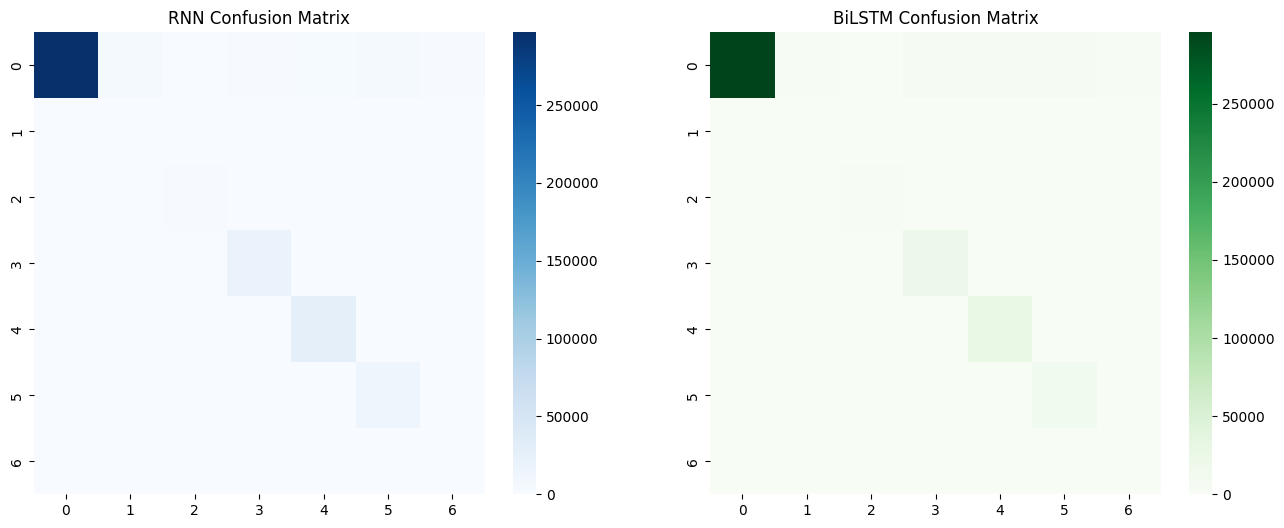

In [17]:
cm_rnn = confusion_matrix(y_test, rnn_pred_classes)
cm_bilstm = confusion_matrix(y_test, bilstm_pred_classes)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.heatmap(cm_rnn, annot=False, cmap='Blues')
plt.title("RNN Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_bilstm, annot=False, cmap='Greens')
plt.title("BiLSTM Confusion Matrix")

plt.show()

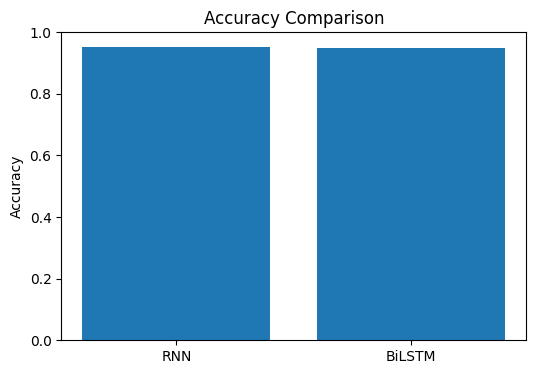

In [18]:
models = ['RNN', 'BiLSTM']
accuracy = [rnn_acc, bilstm_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

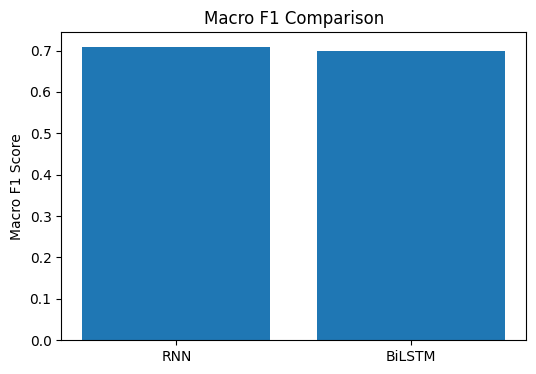

In [19]:
macro_f1 = [0.7086, 0.6979]

plt.figure(figsize=(6,4))
plt.bar(models, macro_f1)
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1 Score")
plt.show()